In [2]:
import os
from langgraph.graph import START,END,add_messages,StateGraph
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage,HumanMessage
from typing import Literal,TypedDict,Annotated
from pydantic import BaseModel
from langgraph.checkpoint.memory import MemorySaver # store chathistory in memory (RAM)


In [3]:
from dotenv import load_dotenv
load_dotenv(dotenv_path='LangGraph/.env')
API_KEY=os.getenv("API_KEY")
llm=ChatGroq(model_name="llama-3.3-70b-versatile",api_key=API_KEY)

In [4]:
# BaseMessage: all types of messages in LangChain are inheritated from this BaseMessage
# add_messages: Buildin Reducer function LangGraph which does not override the updated state instade, 
    # it add updated state one by one
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [5]:
def chat_node(state:ChatState):
    #take user query
    messages=state['messages']
    #send to LLM -> response
    response=llm.invoke(messages)
    #response store state
    return{'messages':messages+ [response]}

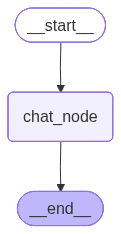

In [6]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)
graph.add_node('chat_node',chat_node)
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)

chatbot

In [7]:
# initial_state={
#     'messages':[HumanMessage(content='What is capital of Maharashtra')]
# }

# chatbot.invoke(initial_state)['messages'][-1].content

In [ ]:

thread_id='1' # thread_id is unique id which tell us who is curretly talking with chatbot 

while True:
    user_message=input("User:")
    print("User:",user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        print("AI: Goodbye!")
        break
    
    config={'configurable':{'thread_id':thread_id}}

    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)

    print('AI:',response['messages'][-1].content)

User: Hii my name is Suraj
AI: Hello Suraj, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: What is my name?
AI: Your name is Suraj.
User: add 100 to 20
AI: 20 + 100 = 120
User: multiply reult with 2
AI: 120 * 2 = 240
User: quit
AI: Goodbye!


In [11]:
# all the chat history is saved in state:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hii my name is Suraj', additional_kwargs={}, response_metadata={}, id='e8f431c0-d4df-43bb-a8ec-a1e5c5395b99'), AIMessage(content="Hello Suraj, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 42, 'total_tokens': 69, 'completion_time': 0.056516854, 'completion_tokens_details': None, 'prompt_time': 0.003992657, 'prompt_tokens_details': None, 'queue_time': 0.055107953, 'total_time': 0.060509511}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d2e1f-67f2-7123-b5e9-0c7755cb6c94-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 27, 'total_tokens': 69}), HumanMessage(content='What is my name?', additional_kwar

In [9]:
# Add Memory to chatbot. This can be achived by concept : Persistence. This allow you to store previous 
# conversation chat history so that chatbot will give response as per pervious chats
# we can store our chat in : RAM or in Database

### Concept of Persistence

In [12]:
from langgraph.checkpoint.memory import InMemorySaver
# InMemorySaver is checkpoint that saves states in Memory: RAM

In [13]:
class JockState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [14]:
def generate_joke(state:JockState):
    topic=state['topic']
    prompt=f"generate joke on the topic {topic}"

    response=llm.invoke(prompt).content

    return{'joke':response}

def generate_explanation(state:JockState):
    joke=state['joke']

    prompt=f'write an explanation for the joke - {joke}'

    response=llm.invoke(prompt).content

    return{'explanation':response}

In [ ]:
graph=StateGraph(JockState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer=InMemorySaver()

workflow=graph.compile(checkpointer=checkpointer)#add checkpointers to the all nodes

In [ ]:
config1={'configurable':{'thread_id':'1'}}# all checkpointers are store against this theread_id:1
workflow.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.',
 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. \n\nIn this joke, "crusty" has a double meaning. In one sense, the crust is a part of a pizza, referring to the outer layer of the pizza that is typically crunchy and crispy. \n\nHowever, "crusty" can also be used to describe someone\'s personality or mood, implying that they are being irritable, grumpy, or short-tempered. \n\nThe joke relies on this wordplay to create humor. It sets up the expectation that the reason for the pizza\'s bad mood will be something complex or unexpected, but instead, it subverts this expectation by using a clever pun on the word "crusty", referencing both the pizza\'s composition and its mood. This unexpected twist creates the humor in the joke.'}

In [17]:
workflow.get_state(config1) #get_state fetch the final state value in the workflow

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. \n\nIn this joke, "crusty" has a double meaning. In one sense, the crust is a part of a pizza, referring to the outer layer of the pizza that is typically crunchy and crispy. \n\nHowever, "crusty" can also be used to describe someone\'s personality or mood, implying that they are being irritable, grumpy, or short-tempered. \n\nThe joke relies on this wordplay to create humor. It sets up the expectation that the reason for the pizza\'s bad mood will be something complex or unexpected, but instead, it subverts this expectation by using a clever pun on the word "crusty", referencing both the pizza\'s composition and its mood. This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns

In [18]:
# get_state_history fetch the intermediate state values
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. \n\nIn this joke, "crusty" has a double meaning. In one sense, the crust is a part of a pizza, referring to the outer layer of the pizza that is typically crunchy and crispy. \n\nHowever, "crusty" can also be used to describe someone\'s personality or mood, implying that they are being irritable, grumpy, or short-tempered. \n\nThe joke relies on this wordplay to create humor. It sets up the expectation that the reason for the pizza\'s bad mood will be something complex or unexpected, but instead, it subverts this expectation by using a clever pun on the word "crusty", referencing both the pizza\'s composition and its mood. This unexpected twist creates the humor in the joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_n

In [25]:
# Another Example

class OrderState(TypedDict):
    order_id: str
    item: str
    payment_done: bool
    shipped: bool
    delivered: bool

In [34]:
def process_payment(state: OrderState) -> dict:
    print(f"💳 Processing payment for order {state['order_id']}")
    return {"payment_done": state['payment_done']}

def ship_order(state: OrderState) -> dict:
    print(f"📦 Shipping item: {state['item']}")
    return {"shipped": state['shipped']}

def deliver_order(state: OrderState) -> dict:
    print(f"🚚 Delivering order {state['order_id']}")
    return {"delivered": state['delivered']}

In [38]:
from langgraph.checkpoint.memory import MemorySaver
graph=StateGraph(OrderState)
graph.add_node('payment',process_payment)
graph.add_node('shipping',ship_order)
graph.add_node('delivary',deliver_order)

graph.add_edge(START,'payment')
graph.add_edge('payment','shipping')
graph.add_edge('shipping','delivary')
graph.add_edge('delivary',END)

checkpointer=MemorySaver()

workflow=graph.compile(checkpointer=checkpointer)

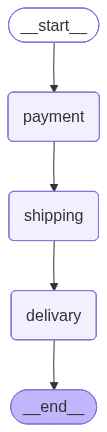

In [39]:
workflow

In [40]:
config = {"configurable": {"thread_id": "order-001"}}

initial_state = {
    "order_id": "order-001",
    "item": "Laptop",
    "payment_done": False,
    "shipped": False,
    "delivered": False
}

result = workflow.invoke(initial_state, config=config)
print(result)

💳 Processing payment for order order-001
📦 Shipping item: Laptop
🚚 Delivering order order-001
{'order_id': 'order-001', 'item': 'Laptop', 'payment_done': False, 'shipped': False, 'delivered': False}


In [41]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'order_id': 'order-001', 'item': 'Laptop', 'payment_done': False, 'shipped': False, 'delivered': False}, next=(), config={'configurable': {'thread_id': 'order-001', 'checkpoint_ns': '', 'checkpoint_id': '1f12c1d6-cca9-6ebf-8003-1b67573cd25c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-30T09:47:11.608779+00:00', parent_config={'configurable': {'thread_id': 'order-001', 'checkpoint_ns': '', 'checkpoint_id': '1f12c1d6-cca8-696b-8002-4d6660ba8787'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'order_id': 'order-001', 'item': 'Laptop', 'payment_done': False, 'shipped': False, 'delivered': False}, next=('delivary',), config={'configurable': {'thread_id': 'order-001', 'checkpoint_ns': '', 'checkpoint_id': '1f12c1d6-cca8-696b-8002-4d6660ba8787'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-30T09:47:11.608237+00:00', parent_config={'configurable': {'thread_id': 'order-001', 'checkpoint_ns': '', 'check

### Fault Tolerance : Benifit of Persistance 
- (Workflow is resume where it CRASH not recompile it again)

In [42]:
import time

In [43]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3:str

In [44]:
from time import sleep


def step_1(state: CrashState)-> CrashState:
    print("✅Step 1 executed")
    return {"step1": "done","input": state['input']}

def step_2(state: CrashState)-> CrashState:
    print("⌛ step 2 hagging... Manually intrupted from notebook")
    time.sleep(30)
    return {"step2":"done"}

def step_3(state: CrashState)-> CrashState:
    print("✅Step 3 executed")
    return {"step3":"done"}

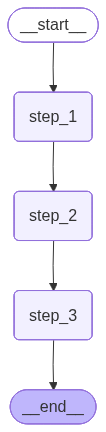

In [45]:
graph=StateGraph(CrashState)
graph.add_node('step_1',step_1)
graph.add_node('step_2',step_2)
graph.add_node('step_3',step_3)

graph.add_edge(START,'step_1')
graph.add_edge('step_1','step_2')
graph.add_edge('step_2','step_3')
graph.add_edge('step_3',END)

checkpointer=MemorySaver()

workflow=graph.compile(checkpointer=checkpointer)

workflow

In [46]:
try:
    print("▶️please intrupt the kernel to stop the execution of step 2 and check the state history")
    workflow.invoke({'input':'start input'},config={'configurable':{'thread_id':'thread-1'}})
except KeyboardInterrupt:
    print("Kernel manually interrupted")

▶️please intrupt the kernel to stop the execution of step 2 and check the state history
✅Step 1 executed
⌛ step 2 hagging... Manually intrupted from notebook
Kernel manually interrupted


In [ ]:
workflow.get_state({'configurable':{'thread_id':'thread-1'}})
# we can see the state of step 1 is done and step 2 is not done because we intrupted the kernel in between the execution of step 2, this show that state is not updated until the node execution is completed.

StateSnapshot(values={'input': 'start input', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8735-6e80-8001-7ba607634b54'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-30T10:24:39.183900+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8732-620f-8000-c11fece0af22'}}, tasks=(PregelTask(id='b3cce179-879e-3cd0-0315-f1afef8905c0', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [50]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'thread-1'}}))
# we can see the state history of all the steps, step 1 is done, step 2 is not done and 
# step 3 is not done because we intrupted the kernel in between the execution of step 2, 
# this show that state is not updated until the node execution is completed.

[StateSnapshot(values={'input': 'start input', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8735-6e80-8001-7ba607634b54'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-30T10:24:39.183900+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8732-620f-8000-c11fece0af22'}}, tasks=(PregelTask(id='b3cce179-879e-3cd0-0315-f1afef8905c0', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start input'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8732-620f-8000-c11fece0af22'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-30T10:24:39.182368+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_

In [51]:
final_state=workflow.invoke(None,config={'configurable':{'thread_id':'thread-1'}})
print(f"\n Final State: {final_state}")

# now workflow will resume from step2 because step 2 is not completed and state is not updated for step 2, 
# once step 2 is completed then state will be updated and workflow will move to step 3 and 
# complete the execution.

⌛ step 2 hagging... Manually intrupted from notebook
✅Step 3 executed

 Final State: {'input': 'start input', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [52]:
workflow.get_state(config={'configurable':{'thread_id':'thread-1'}})

StateSnapshot(values={'input': 'start input', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c23f-0ea6-67af-8003-ca7b3c1850d3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-30T10:33:50.256714+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c23f-0ea2-627c-8002-317c8387190a'}}, tasks=(), interrupts=())

In [53]:
list(workflow.get_state_history(config={'configurable':{'thread_id':'thread-1'}}))

[StateSnapshot(values={'input': 'start input', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c23f-0ea6-67af-8003-ca7b3c1850d3'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-30T10:33:50.256714+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c23f-0ea2-627c-8002-317c8387190a'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start input', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c23f-0ea2-627c-8002-317c8387190a'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-30T10:33:50.254924+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f12c22a-8735-6e80-8001-7ba607634b54'}}, tasks=(PregelTask(id='586489